In [1]:
from s2gos_apps.processes.common import generation, simulation
from s2gos_apps.processes.gobabeb import generation_configs, simulation_configs
import xarray as xr

In [3]:
scene_name = "gobabeb"
target_lat = -23.6015417
target_lon = 15.1258696
target_size = 10
gmt_hour = 9
spp = 8

# expands the parameters passed to full configuration files for generation and simulation
gen_config_path = generation_configs(
    scene_name=scene_name,
    target_lat=target_lat,
    target_lon=target_lon,
    target_size=target_size,
    config_output_dir="./use_cases/gen_config",
    scene_output_dir="./use_cases/gen_output",
)["return_value"]

sim_config_path = simulation_configs(
    scene_name=scene_name,
    target_lat=target_lat,
    target_lon=target_lon,
    target_size=target_size,
    gmt_hour=gmt_hour,
    config_output_dir="./use_cases/sim_config",
)["return_value"]



Configuring generation...
Basic configuration created
Configuration validation passed
[mitsuba] Warning: Couldn't import the ipywidgets package. Installing this package is required for the system to properly log messages and print in Jupyter notebooks!


/home/gonzalezm/test/test2/s2gos-mono/.pixi/envs/default/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:joseki.profiles.factory:Registering profile afgl_1986-tropical
INFO:joseki.profiles.factory:Registering profile afgl_1986-midlatitude_summer
INFO:joseki.profiles.factory:Registering profile afgl_1986-midlatitude_winter
INFO:joseki.profiles.factory:Registering profile afgl_1986-subarctic_summer
INFO:joseki.profiles.factory:Registering profile afgl_1986-subarctic_winter
INFO:joseki.profiles.factory:Registering profile afgl_1986-us_standard
INFO:joseki.profiles.factory:Registering profile mipas_2007-midlatitude_day
INFO:joseki.profiles.factory:Registering profile mipas_2007-midlatitude_night
INFO:joseki.profiles.factory:Registering profile mipas_2007-polar_summer
INFO:joseki.profiles.factory:Regist



Configuring simulation...
Simulation configured:
  Sensors: 1
    1. rgb_camera (uav/perspective_camera)
  Saved: simulation_config.json


In [4]:
# generate the 3D scene description from the generation config
scene_description_path = generation.generation(config_path=gen_config_path)["return_value"]

INFO:root:Registered 14 resources:
INFO:root:  Core (6): aoi, target_dem, target_landcover, target_mesh, target_texture, scene_description
INFO:root:  Buffer (5): buffer_aoi, buffer_dem, buffer_landcover, buffer_mesh, buffer_texture
INFO:root:  Background (3): background_aoi, background_landcover, background_texture
INFO:root:Pipeline initialized for scene 'gobabeb'
INFO:root:Pipeline visualization saved to: use_cases/gen_output/gobabeb/gobabeb_dag.png
INFO:root:AOI corners (lon, lat):
INFO:root:  Corner 1: (-23.646680, 15.076863)
INFO:root:  Corner 2: (-23.646680, 15.174876)
INFO:root:  Corner 3: (-23.556388, 15.174842)
INFO:root:  Corner 4: (-23.556388, 15.076897)
INFO:root:AOI polygon: 10.0km x 10.0km at (-23.601542, 15.125870)




Generating scene description...
Configuration validation

Configuration Summary:
  Scene: gobabeb
  Location: -23.6015°, 15.1259°
  AOI: 10.0 km²
  Resolution: 10.0 m
Generating scene with configuration

Generating DAG visualization
DAG saved to: use_cases/gen_output/gobabeb/gobabeb_dag.png

Resource execution order:
  aoi (depends on: none)
  target_dem (depends on: ['aoi'])
  target_landcover (depends on: ['aoi'])
  target_mesh (depends on: ['target_dem'])
  target_texture (depends on: ['target_landcover'])
  buffer_aoi (depends on: ['aoi'])
  buffer_dem (depends on: ['buffer_aoi'])
  buffer_landcover (depends on: ['buffer_aoi'])
  buffer_mesh (depends on: ['buffer_dem'])
  buffer_texture (depends on: ['buffer_landcover'])
  background_aoi (depends on: ['aoi'])
  background_landcover (depends on: ['background_aoi'])
  background_texture (depends on: ['background_landcover'])
  scene_description (depends on: ['target_mesh', 'target_texture', 'buffer_mesh', 'buffer_texture', 'backgro

INFO:root:DEM saved to use_cases/gen_output/gobabeb/data/dem_gobabeb_10.0m.zarr
INFO:root:Target DEM: use_cases/gen_output/gobabeb/data/dem_gobabeb_10.0m.zarr
INFO:root:ESA Worldcover 2021 saved to use_cases/gen_output/gobabeb/data/landcover_gobabeb_10.0m.zarr
INFO:root:Target landcover (10.0m): use_cases/gen_output/gobabeb/data/landcover_gobabeb_10.0m.zarr
INFO:root:Mesh saved to use_cases/gen_output/gobabeb/meshes/gobabeb_terrain.ply
INFO:root:Target mesh: use_cases/gen_output/gobabeb/meshes/gobabeb_terrain.ply
INFO:root:Texture: use_cases/gen_output/gobabeb/textures/gobabeb_10.0m_selection.png
INFO:root:Target texture: use_cases/gen_output/gobabeb/textures/gobabeb_10.0m_selection.png
INFO:root:DEM saved to use_cases/gen_output/gobabeb/data/dem_buffer_gobabeb_60.0m.zarr
INFO:root:ESA Worldcover 2021 saved to use_cases/gen_output/gobabeb/data/landcover_buffer_gobabeb_60.0m.zarr
INFO:root:Buffer landcover (60.0m): use_cases/gen_output/gobabeb/data/landcover_buffer_gobabeb_60.0m.zarr
IN

Scene generated successfully!
 Location: -23.6015417, 15.1258696
 Target: 10.0km² at 10.0m
  Buffer: 60.0km at 60.0m
  Background: 150.0km at 200.0m
  Output: use_cases/gen_output/gobabeb

Output directory: use_cases/gen_output/gobabeb


In [5]:
# simulate an observation from the scene description and simulation config
simulation_output_dir = simulation.simulation(
    scene_description_path=f"./use_cases/gen_output/{scene_name}/{scene_name}.yml",
    config_path=sim_config_path,
    simulation_output_dir=f"./use_cases/sim_output/{scene_name}",
)["return_value"]

INFO:s2gos_simulator.backends.eradiate.backend:Simulation: config_simulation
INFO:s2gos_simulator.backends.eradiate.backend:  Sensors: 1
INFO:s2gos_simulator.backends.eradiate.backend:  Measurements: none
INFO:s2gos_simulator.backends.eradiate.backend:
Standard workflow
INFO:s2gos_simulator.backends.eradiate.backend:============================================================
INFO:s2gos_simulator.backends.eradiate.backend:Running experiments
INFO:s2gos_simulator.backends.eradiate.backend:============================================================
INFO:root:Successfully loaded spectral data: /home/gonzalezm/test/test2/s2gos-apps/packages/s2gos-generator/resources/data/spectra/spectrum_baresoil_high.nc (variable: reflectance)
INFO:root:Successfully loaded spectral data: /home/gonzalezm/test/test2/s2gos-apps/packages/s2gos-generator/resources/data/spectra/spectrum_concrete.nc (variable: reflectance)
INFO:root:Successfully loaded spectral data: /home/gonzalezm/test/test2/s2gos-apps/packag



Simulating observation...

Validating materials and running simulation...
Available materials: ['baresoil', 'concrete', 'cropland', 'grassland', 'mangroves', 'moss', 'rough_aluminum', 'shrubland', 'snow', 'treecover', 'water', 'wetland']
OK: All 0 object material references are valid


INFO:joseki.core:Creating profile afgl_1986-us_standard
INFO:joseki.profiles.schema:Dataset is valid
INFO:root:Material validation passed - no issues found
INFO:joseki.profiles.schema:Dataset is valid
INFO:s2gos_simulator.backends.eradiate.backend:  Measure 1/1: rgb_camera
INFO:eradiate.experiments._core:Initializing kernel scene
INFO:joseki.profiles.schema:Dataset is valid
INFO:eradiate.experiments._core:Launching simulation
Eradiate [660 nm]: 3/3|██████████| 00:04, ETA=00:00
INFO:eradiate.experiments._core:Post-processing results
INFO:s2gos_simulator.processors.sensor_processor:RGB generation for rgb_camera: R=660.0nm, G=550.0nm, B=440.0nm
INFO:s2gos_simulator.processors.sensor_processor:RGB image saved: use_cases/sim_output/gobabeb/rgb_camera_rgb.png
INFO:s2gos_simulator.backends.eradiate.result_processor:Saved 'rgb_camera_raw_eradiate' → config_simulation_rgb_camera_raw_eradiate.zarr
INFO:s2gos_simulator.backends.eradiate.result_processor:Saved 'rgb_camera' → config_simulation_rgb_

Simulation completed successfully!

Output directory: ./use_cases/sim_output/gobabeb


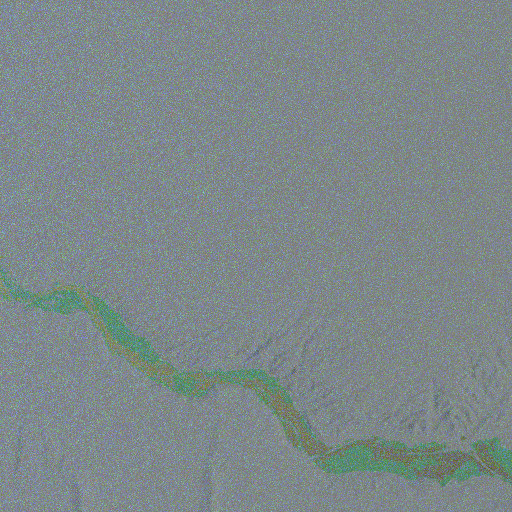

In [6]:
from IPython.display import Image, display

display(Image(filename="use_cases/sim_output/gobabeb/rgb_camera_rgb.png"))